<a href="https://colab.research.google.com/github/mohammadsanatabassum/labs-and-projects-on-aiml-/blob/main/AIML_Module_4_Lab_3_Gradient_Descent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Module 4: Perceptron and Gradient DescentModule 4: Perceptron and Gradient Descent

Lab 3: Gradient Descent

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
np.random.seed(42)

In [4]:
X = 5 * np.random.rand(100, 1)
y = 9 + 9 * X + np.random.randn(100, 1)

Text(0, 0.5, 'y')

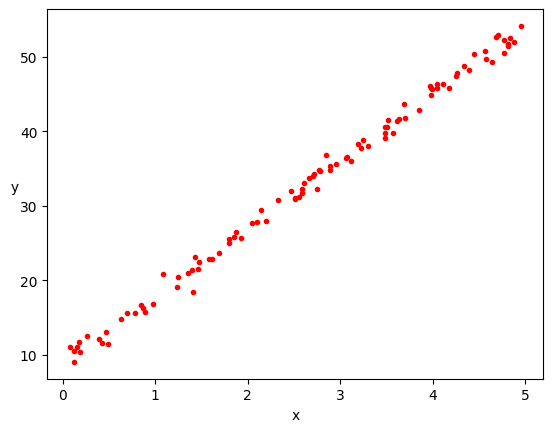

In [7]:
plt.plot(X, y, 'r.')
plt.xlabel('x')
plt.ylabel('y', rotation=1)

In [8]:
def cal_cost(y_pred, X, y):


    m = len(y)

    predictions = X.dot(y_pred)
    cost = (1 / 2 * m) * np.sum(np.square(predictions - y))

    return cost

In [9]:
def gradient_descent(X, y, y_pred, learning_rate=0.05, iterations=150):


    m = len(y)
    cost_history = np.zeros(iterations)
    y_pred_history = np.zeros((iterations, 2))

    for it in range(iterations):
        prediction = np.dot(X, y_pred)
        y_pred = y_pred - (1 / m) * learning_rate * (X.T.dot((prediction - y)))
        y_pred_history[it,:] = y_pred.T
        cost_history[it]  = cal_cost(y_pred, X, y)

    return y_pred, cost_history, y_pred_history

In [11]:
lr = 0.05
n_iter = 1500

y_pred = np.random.randn(2,1)
X_b = np.c_[np.ones((len(X), 1)), X]
y_pred, cost_history, y_pred_history = gradient_descent(X_b, y, y_pred, lr, n_iter)

print('y_pred[0]: {:0.3f}\ny_pred[1]: {:0.3f}'.format(y_pred[0][0], y_pred[1][0]))
print('Final error: {:0.3f}'.format(cost_history[-1]))

y_pred[0]: 8.865
y_pred[1]: 9.056
Final error: 3974.089


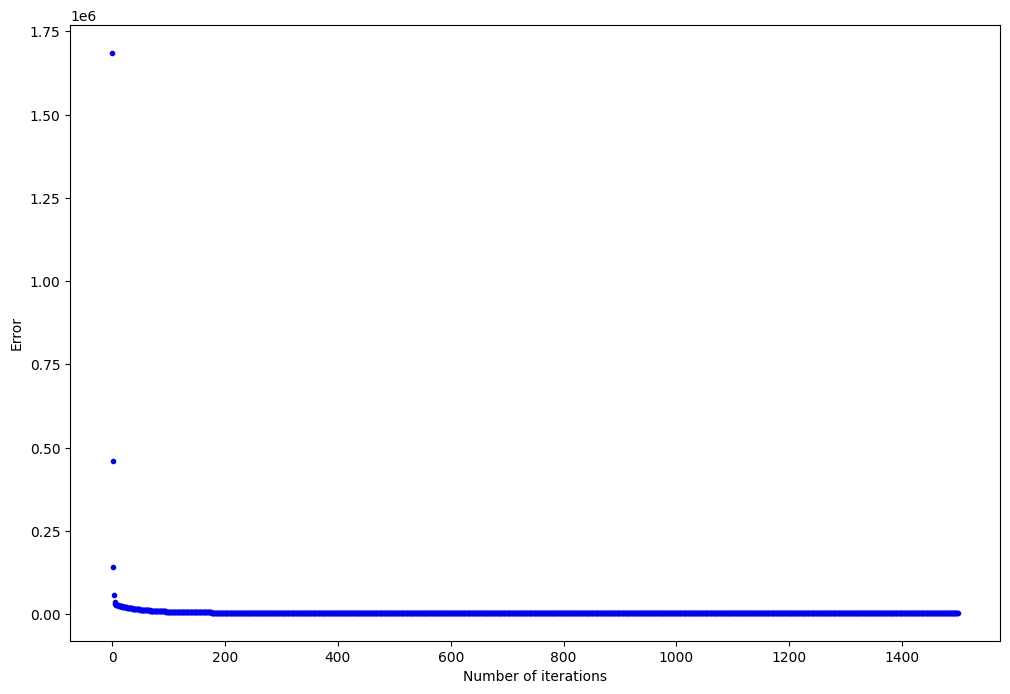

In [13]:
fig, ax = plt.subplots(figsize=(12,8))

ax.set_ylabel('Error')
ax.set_xlabel('Number of iterations')

ax.plot(range(n_iter), cost_history, 'b.')

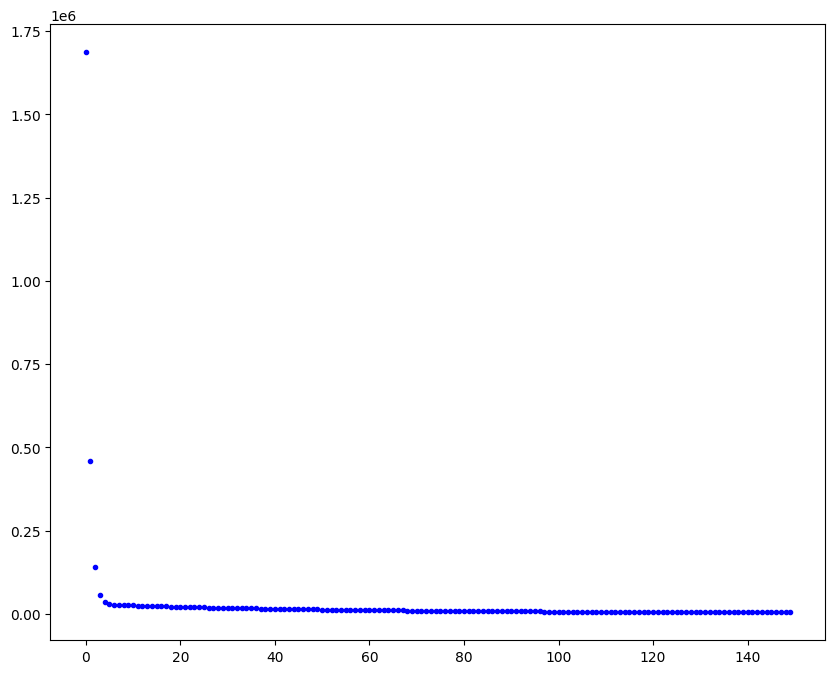

In [14]:
fig,ax = plt.subplots(figsize=(10,8))
ax.plot(range(150), cost_history[:150], 'b.')

In [15]:
def stocashtic_gradient_descent(X, y, y_pred, learning_rate=0.01, iterations=10):

    m = len(y)
    cost_history = np.zeros(iterations)

    for it in range(iterations):
        cost = 0.0

        for i in range(m):
            rand_ind = np.random.randint(0,m)
            X_i = X[rand_ind, :].reshape(1, X.shape[1])
            y_i = y[rand_ind].reshape(1,1)
            prediction = np.dot(X_i, y_pred)

            y_pred = y_pred - (1 / m) * learning_rate *(X_i.T.dot((prediction - y_i)))
            cost += cal_cost(y_pred, X_i, y_i)

        cost_history[it]  = cost

    return y_pred, cost_history

In [18]:
lr = 0.5
n_iter = 100
y_pred = np.random.randn(2, 1)
X_b = np.c_[np.ones((len(X), 1)), X]
y_pred, cost_history = stocashtic_gradient_descent(X_b, y, y_pred, lr, n_iter)

print('y_pred[0]: {:0.5f}\ny_pred[1]: {:0.5f}'.format(y_pred[0][0], y_pred[1][0]))
print('Final error: {:0.5f}'.format(cost_history[-1]))

y_pred[0]: 8.84365
y_pred[1]: 9.13526
Final error: 36.10398


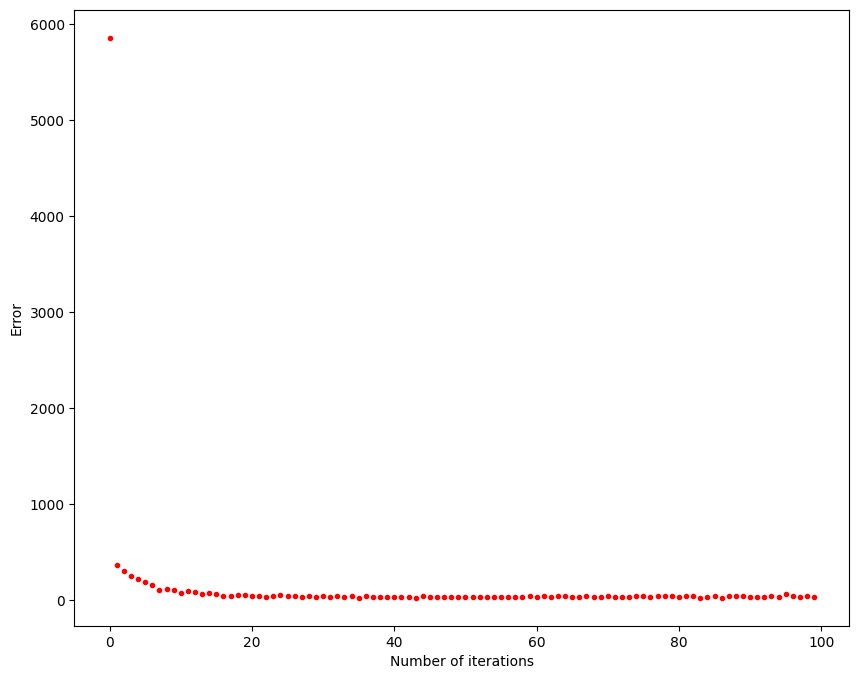

In [19]:
fig, ax = plt.subplots(figsize=(10,8))

ax.set_ylabel('Error')
ax.set_xlabel('Number of iterations')
y_pred = np.random.randn(2,1)

ax.plot(range(n_iter), cost_history, 'r.')

In [20]:
def minibatch_gradient_descent(X, y, y_pred, learning_rate=0.01, iterations=10, batch_size=50):


    m = len(y)
    cost_history = np.zeros(iterations)
    n_batches = int(m / batch_size)

    for it in range(iterations):
        cost = 0.0
        indices = np.random.permutation(m)
        X = X[indices]
        y = y[indices]

        for i in range(0, m, batch_size):
            X_i = X[i: i + batch_size]
            y_i = y[i: i + batch_size]

            X_i = np.c_[np.ones(len(X_i)), X_i]
            prediction = np.dot(X_i, y_pred)

            y_pred = y_pred - (1 / m) * learning_rate * (X_i.T.dot((prediction - y_i)))
            cost += cal_cost(y_pred, X_i, y_i)

        cost_history[it]  = cost

    return y_pred, cost_history

In [21]:
lr = 0.1
n_iter = 300
y_pred = np.random.randn(2,1)
y_pred, cost_history = minibatch_gradient_descent(X, y, y_pred, lr, n_iter)

print('y_pred[0]: {:0.3f}\ny_pred[1]: {:0.3f}'.format(y_pred[0][0], y_pred[1][0]))
print('Final error: {:0.3f}'.format(cost_history[-1]))

y_pred[0]: 8.851
y_pred[1]: 9.051
Final error: 1965.212


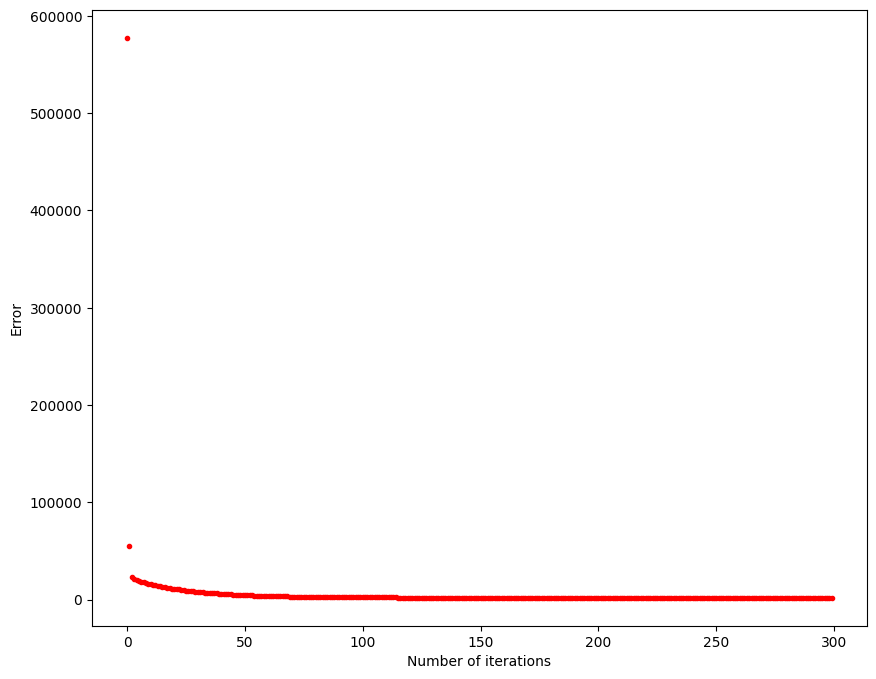

In [22]:
fig, ax = plt.subplots(figsize=(10,8))

ax.set_ylabel('Error')
ax.set_xlabel('Number of iterations')
y_pred = np.random.randn(2,1)

ax.plot(range(n_iter), cost_history, 'r.')



Which of the following is TRUE, given the optimal learning rate?

(i) Batch gradient descent is always guaranteed to converge to the global optimum of a loss function.

(ii) Stochastic gradient descent is always guaranteed to converge to the global optimum of a loss function.

(iii) For convex loss functions (i.e. with a bowl shape), batch gradient descent is guaranteed to eventually converge to the global optimum while stochastic gradient descent is not.

(iv) For convex loss functions (i.e. with a bowl shape), stochastic gradient descent is guaranteed to eventually converge to the global optimum while batch gradient descent is not.

(v) For convex loss functions (i.e. with a bowl shape), both stochastic gradient descent and batch gradient descent will eventually converge to the global optimum.

(vi) For convex loss functions (i.e. with a bowl shape), neither stochastic gradient descent nor batch gradient descent are guaranteed to converge to the global optimum.


Correct Answer:

(v) For convex loss functions (i.e. with a bowl shape), both stochastic gradient descent and batch gradient descent will eventually converge to the global optimum.

Convex Loss Functions:

    Convex loss functions have a single global minimum, which ensures that gradient-based methods (e.g., gradient descent) can eventually find the global optimum when an appropriate learning rate is used.

Batch Gradient Descent:

    Batch Gradient Descent (BGD) computes the gradient of the entire dataset at every step.
    For convex functions and an optimal learning rate, BGD will converge to the global optimum. However, it is computationally expensive for large datasets.

Stochastic Gradient Descent:

    Stochastic Gradient Descent (SGD) updates the parameters based on a single randomly chosen example at each iteration. This introduces noise in the updates.
    Although SGD can be noisier, for convex functions and proper tuning (e.g., decreasing learning rates over time), SGD can also converge to the global optimum.


    Change batch size in mini-batch gradient descent.
    Test all the three out on real datasets.
    Compare the effects of changing learning rate by the same amount in Batch GD, SGD and Mini-batch GD.


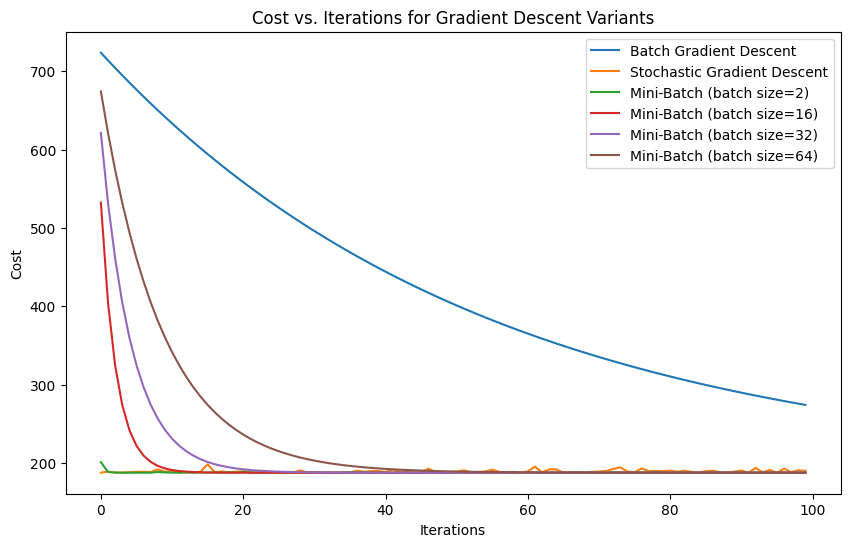

In [23]:
import numpy as np
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Generate synthetic data for regression
X, y = make_regression(n_samples=500, n_features=1, noise=20)
y = y.reshape(-1, 1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Helper: Compute cost
def compute_cost(X, y, theta):
    m = len(y)
    predictions = X.dot(theta)
    return (1 / (2 * m)) * np.sum(np.square(predictions - y))

# Gradient Descent Algorithms
def batch_gradient_descent(X, y, theta, learning_rate, iterations):
    m = len(y)
    cost_history = []
    for _ in range(iterations):
        gradients = (1 / m) * X.T.dot(X.dot(theta) - y)
        theta -= learning_rate * gradients
        cost_history.append(compute_cost(X, y, theta))
    return theta, cost_history

def stochastic_gradient_descent(X, y, theta, learning_rate, iterations):
    m = len(y)
    cost_history = []
    for _ in range(iterations):
        for i in range(m):
            rand_index = np.random.randint(m)
            X_i = X[rand_index:rand_index+1]
            y_i = y[rand_index:rand_index+1]
            gradients = X_i.T.dot(X_i.dot(theta) - y_i)
            theta -= learning_rate * gradients
        cost_history.append(compute_cost(X, y, theta))
    return theta, cost_history

def mini_batch_gradient_descent(X, y, theta, learning_rate, iterations, batch_size):
    m = len(y)
    cost_history = []
    for _ in range(iterations):
        indices = np.random.permutation(m)
        X_shuffled = X[indices]
        y_shuffled = y[indices]
        for i in range(0, m, batch_size):
            X_i = X_shuffled[i:i + batch_size]
            y_i = y_shuffled[i:i + batch_size]
            gradients = (1 / batch_size) * X_i.T.dot(X_i.dot(theta) - y_i)
            theta -= learning_rate * gradients
        cost_history.append(compute_cost(X, y, theta))
    return theta, cost_history

# Run experiments
X_train = np.c_[np.ones((X_train.shape[0], 1)), X_train]  # Add bias term
X_test = np.c_[np.ones((X_test.shape[0], 1)), X_test]
theta = np.random.randn(2, 1)
learning_rate = 0.01
iterations = 100

# Batch Gradient Descent
theta_bgd, cost_bgd = batch_gradient_descent(X_train, y_train, theta.copy(), learning_rate, iterations)

# Stochastic Gradient Descent
theta_sgd, cost_sgd = stochastic_gradient_descent(X_train, y_train, theta.copy(), learning_rate, iterations)

# Mini-Batch Gradient Descent with varying batch sizes
batch_sizes = [2, 16, 32, 64]
results_mbgd = {}
for batch_size in batch_sizes:
    theta_mbgd, cost_mbgd = mini_batch_gradient_descent(X_train, y_train, theta.copy(), learning_rate, iterations, batch_size)
    results_mbgd[batch_size] = cost_mbgd

# Plot Results
plt.figure(figsize=(10, 6))
plt.plot(cost_bgd, label='Batch Gradient Descent')
plt.plot(cost_sgd, label='Stochastic Gradient Descent')
for batch_size, cost in results_mbgd.items():
    plt.plot(cost, label=f'Mini-Batch (batch size={batch_size})')
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.title('Cost vs. Iterations for Gradient Descent Variants')
plt.legend()
plt.show()
